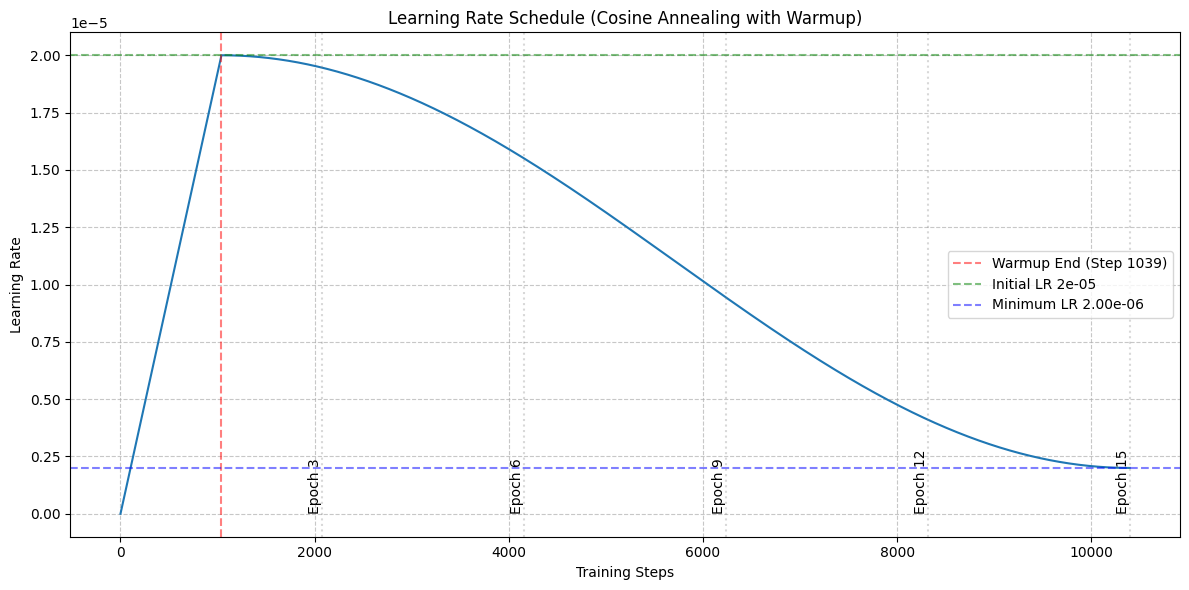

Total training steps: 10395
Warmup steps: 1039 (10.0%)
Initial learning rate: 2e-05
Minimum learning rate: 2.00e-06
Total training epochs: 15
Steps per epoch: 693


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import LambdaLR

# Given parameters
total_epochs = 15
steps_per_epoch = 693
initial_lr = 2e-5  # Initial learning rate

# Define learning rate scheduler function
def get_cosine_scheduler(optimizer, total_epochs, steps_per_epoch):
    """
    Create a learning rate scheduler with cosine annealing and warmup
    """
    total_steps = steps_per_epoch * total_epochs
    warmup_steps = max(1, int(0.1 * total_steps))  # First 10% steps for warmup
    min_lr_ratio = 0.1  # Minimum LR is 10% of max LR

    def lr_lambda(step):
        # Linear warmup phase
        if step < warmup_steps:
            return step / warmup_steps
        # Cosine annealing phase
        else:
            progress = (step - warmup_steps) / (total_steps - warmup_steps)
            cosine_decay = 0.5 * (1 + np.cos(np.pi * progress))
            return min_lr_ratio + (1 - min_lr_ratio) * cosine_decay

    return LambdaLR(optimizer, lr_lambda)

# For plotting, no actual optimizer needed - simulate LR calculation
total_steps = steps_per_epoch * total_epochs
warmup_steps = max(1, int(0.1 * total_steps))

# Generate learning rates for all steps
steps = np.arange(total_steps)
lrs = []

for step in steps:
    if step < warmup_steps:
        lr_ratio = step / warmup_steps
    else:
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        cosine_decay = 0.5 * (1 + np.cos(np.pi * progress))
        lr_ratio = 0.1 + (1 - 0.1) * cosine_decay
    lrs.append(initial_lr * lr_ratio)

# Plot learning rate curve
plt.figure(figsize=(12, 6))
plt.plot(steps, lrs)
plt.title('Learning Rate Schedule (Cosine Annealing with Warmup)')
plt.xlabel('Training Steps')
plt.ylabel('Learning Rate')
plt.grid(True, linestyle='--', alpha=0.7)

# Mark key points
plt.axvline(x=warmup_steps, color='r', linestyle='--', alpha=0.5, 
            label=f'Warmup End (Step {warmup_steps})')
plt.axhline(y=initial_lr, color='g', linestyle='--', alpha=0.5, 
            label=f'Initial LR {initial_lr}')
plt.axhline(y=initial_lr * 0.1, color='b', linestyle='--', alpha=0.5, 
            label=f'Minimum LR {initial_lr * 0.1:.2e}')

# Add epoch markers
for epoch in range(1, total_epochs + 1):
    if epoch % 3 == 0:  # Mark every 3 epochs to avoid clutter
        step = epoch * steps_per_epoch
        plt.axvline(x=step, color='gray', linestyle=':', alpha=0.3)
        plt.text(step, min(lrs), f'Epoch {epoch}', rotation=90, va='bottom', ha='right')

plt.legend()
plt.tight_layout()
plt.show()

# Print key information
print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {warmup_steps} ({warmup_steps/total_steps*100:.1f}%)")
print(f"Initial learning rate: {initial_lr}")
print(f"Minimum learning rate: {initial_lr * 0.1:.2e}")
print(f"Total training epochs: {total_epochs}")
print(f"Steps per epoch: {steps_per_epoch}")